In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embedding = model.encode("Machine learning is powerful")
print(len(embedding))

/Users/gokulbj/Documents/WorkSpace/AI-ML-Learning-Notes/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9848.93it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


384


In [17]:
def get_embedding(text):
    return model.encode(text)

embedding = model.encode("Machine learning is powerful")
print(embedding)

[ 1.86186600e-02 -2.60737725e-02  7.28660524e-02 -2.13887251e-04
  1.67402485e-03 -3.85750942e-02 -4.06430103e-02 -3.62383015e-02
 -2.58624982e-02 -1.43490052e-02 -7.44078606e-02  7.03515932e-02
  1.73038617e-02 -1.88038647e-02 -4.03556973e-02  4.09649014e-02
  1.30757606e-02 -1.75414681e-02 -1.42114773e-01 -1.50779039e-01
 -2.66181603e-02  1.20002236e-02 -1.77375618e-02 -2.25742590e-02
  5.69020957e-02  3.26470509e-02 -2.87273922e-03  1.53476959e-02
  4.91951592e-02 -6.48741871e-02  1.93073545e-02 -3.31372283e-02
 -1.78547073e-02  3.97013016e-02 -1.32063895e-01  3.20773311e-02
 -5.94981993e-03  3.61691453e-02  6.60445020e-02  3.93294357e-02
 -1.92463845e-02 -4.05940488e-02 -2.80722999e-03 -1.67869199e-02
  1.05767868e-01  8.16190690e-02 -4.45911549e-02 -2.61936989e-02
 -2.10753595e-03  2.78250519e-02 -1.41551122e-01 -5.29652424e-02
 -3.13568152e-02 -2.02248450e-02 -5.97695261e-02  1.36744697e-02
  8.27643555e-03 -4.84216288e-02  3.69659290e-02 -2.26368755e-03
 -2.56600101e-02 -5.76222

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.decomposition import PCA

def visualize_pca_2d(embeddings, words):
    pca_2d = PCA(n_components=2)
    embeddings_2d = pca_2d.fit_transform(embeddings)

    # Create a 2D scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], marker='o')
    for i, word in enumerate(words):
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("2D Visualization of Word Embeddings")
    plt.grid(True)
    plt.show()

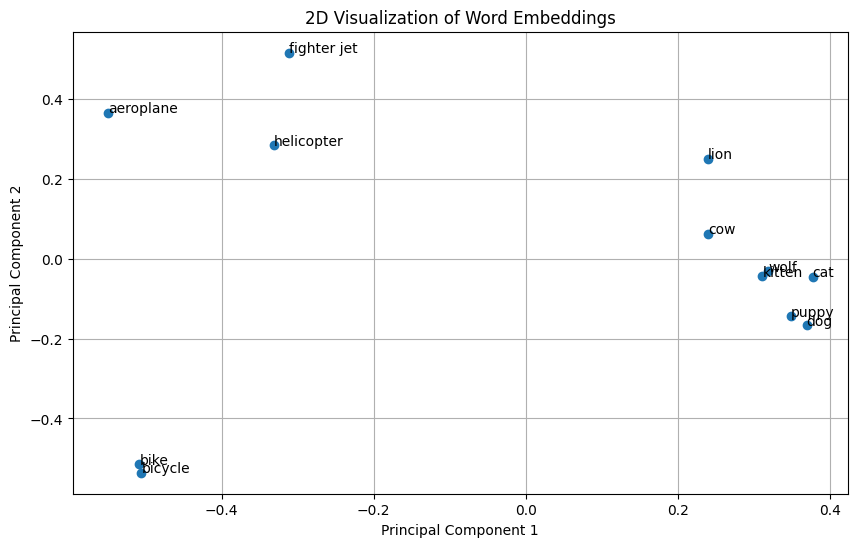

In [6]:
words = ['cat', 'dog', 'bike', 'kitten', 'puppy', 'bicycle', 'aeroplane', 'helicopter', 'cow', 'wolf', 'lion', 'fighter jet']
embeddings = []
for i in words:
    embeddings.append(get_embedding(i))
visualize_pca_2d(embeddings, words)

In [7]:
import numpy as np

def calculate_distance(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.sum((a-b)**2)

cat = get_embedding('cat')
dog = get_embedding('dog')

distance_cat_dog = calculate_distance(cat, dog)
print(f"Distance between 'cat' and 'dog': {distance_cat_dog:.2f}")

Distance between 'cat' and 'dog': 0.68


In [8]:
def triplet_distance(a, b, c, model='text-embedding-3-small'):
    ae = get_embedding(a)
    be = get_embedding(b)
    ce = get_embedding(c)
    dab = calculate_distance(ae, be)
    dac = calculate_distance(ae, ce)
    dbc = calculate_distance(be, ce)
    print(f"{a} <> {b}: {dab}")
    print(f"{a} <> {c}: {dac}")
    print(f"{b} <> {c}: {dbc}")

triplet_distance('Heart Attack', 'Yoga', 'Cardiologist')

Heart Attack <> Yoga: 1.4597526788711548
Heart Attack <> Cardiologist: 0.9843982458114624
Yoga <> Cardiologist: 1.687941551208496


In [9]:
triplet_distance('The product is amazing', 'positive', 'negative')

The product is amazing <> positive: 1.5625460147857666
The product is amazing <> negative: 1.8649742603302002
positive <> negative: 0.5724614262580872


In [10]:
embeddings_bad_review = np.array(get_embedding('The product is not good'))
embd_positive = np.array(get_embedding('positive'))
embd_neg = np.array(get_embedding('negative'))

print("Similarity with positive: ", np.dot(embeddings_bad_review, embd_positive))
print("Similarity with negative: ", np.dot(embeddings_bad_review, embd_neg))

Similarity with positive:  0.2826398
Similarity with negative:  0.24929094


In [15]:
def semantic_search(query, documents):
    query_embedding = get_embedding(query)
    document_embeddings = [get_embedding(doc) for doc in documents]

    similarities = [np.dot(query_embedding, doc_emb) for doc_emb in document_embeddings]
    best_match_index = np.argmax(similarities)
    
    return documents[best_match_index], similarities[best_match_index]

documents = [
    "Laptop with 16GB RAM and 512GB SSD",
    "Smartphone with 8GB RAM and 128GB storage",
    "Tablet with 4GB RAM and 64GB storage"
]

query = "I need a device with a lot of memory for work"
best_match, similarity = semantic_search(query, documents)
print(f"Best match: {best_match} with similarity score: {similarity:.4f}")

query = "I need a PC with high performance for gaming"
best_match, similarity = semantic_search(query, documents)
print(f"Best match: {best_match} with similarity score: {similarity:.4f}")

Best match: Smartphone with 8GB RAM and 128GB storage with similarity score: 0.5573
Best match: Laptop with 16GB RAM and 512GB SSD with similarity score: 0.3481


In [ ]:
diseases = [
    {
        "name": "Flu",
        "symptoms": "fever cough sore throat body ache fatigue chills"
    },
    {
        "name": "Common Cold",
        "symptoms": "runny nose sneezing cough congestion mild fever"
    },
    {
        "name": "Migraine",
        "symptoms": "severe headache nausea vomiting light sensitivity"
    },
    {
        "name": "Food Poisoning",
        "symptoms": "vomiting diarrhea stomach pain nausea dehydration"
    },
    {
        "name": "Dengue",
        "symptoms": "high fever headache joint pain rash fatigue"
    }
]

disease_texts = [d["symptoms"] for d in diseases]
disease_embeddings = [get_embedding(text) for text in disease_texts]


def predict_disease(query, k=3):

    query_embedding = get_embedding(query)

    similarities = [
        np.dot(query_embedding, emb) for emb in disease_embeddings
    ]

    top_indices = np.argsort(similarities)[-k:][::-1]

    results = []

    for i in top_indices:
        results.append({
            "disease": diseases[i]["name"],
            "similarity": float(similarities[i])
        })

    return results


query = "I have fever, body pain and chills"
results = predict_disease(query)
print("Possible diseases:\n")

for r in results:
    print(f"{r['disease']}  -> similarity {r['similarity']:.4f}")

Possible diseases:

Flu  -> similarity 0.6929
Dengue  -> similarity 0.5593
Common Cold  -> similarity 0.4522
